In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
df = pd.read_csv('data_cleaned.csv')
df

,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,1,14.75,1,0.524977,0.316667,0.783333,0.450000,0.000000,0.615000,0,0,1,0,0,0
1,2,0,NaN,0,0.454259,0.405556,0.200000,0.283333,0.000000,0.498333,0,1,0,0,0,0
2,2,1,19.06,1,0.559051,0.355556,0.566667,0.531667,0.000000,0.672167,0,0,0,1,0,0
3,2,0,NaN,0,0.430833,0.222222,0.283333,0.413333,0.000000,0.589333,0,0,0,0,0,0
4,2,1,13.42,1,0.336759,0.350000,0.433333,0.451667,0.333333,0.516167,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,0,NaN,0,0.517454,0.683333,0.316667,0.346667,0.000000,0.542667,0,0,0,0,1,0
99996,3,1,16.58,1,0.518403,0.366667,0.308333,0.576667,0.000000,0.703667,0,0,0,0,1,0
99997,2,1,17.24,1,0.482014,0.616667,0.225000,0.656667,0.000000,0.759667,0,0,0,1,0,0
99998,3,1,17.01,1,0.487454,0.427778,0.283333,0.438333,0.000000,0.606833,0,0,0,0,0,1


In [19]:
df['salary_package_lpa'].fillna(0 , inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_35848\2452213253.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary_package_lpa'].fillna(0 , inplace=True)


In [20]:
df.describe()

,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2.30354,0.684750,11.851663,0.684750,0.474023,0.469106,0.329644,0.534397,0.182337,0.619377,0.25046,0.098260,0.149390,0.120920,0.16065,0.120080
std,0.71328,0.464618,8.324667,0.464618,0.081220,0.180741,0.150502,0.154206,0.287576,0.138437,0.43328,0.297667,0.356474,0.326036,0.36721,0.325057
min,1.00000,0.000000,0.000000,0.000000,0.149977,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,2.00000,0.000000,0.000000,0.000000,0.418032,0.327778,0.216667,0.430000,0.000000,0.533333,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,2.00000,1.000000,15.680000,1.000000,0.472477,0.455556,0.316667,0.535000,0.000000,0.628167,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,3.00000,1.000000,18.160000,1.000000,0.528403,0.600000,0.433333,0.638333,0.333333,0.715333,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000
max,3.00000,1.000000,28.330000,1.000000,0.816736,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   college_tier        100000 non-null  int64  
 1   placement_status    100000 non-null  int64  
 2   salary_package_lpa  100000 non-null  float64
 3   salary_available    100000 non-null  int64  
 4   tech_skill          100000 non-null  float64
 5   soft_skill          100000 non-null  float64
 6   practical_skill     100000 non-null  float64
 7   cgpa_scaled         100000 non-null  float64
 8   backlogs_scaled     100000 non-null  float64
 9   academic_points     100000 non-null  float64
 10  branch_CSE          100000 non-null  int64  
 11  branch_Chemical     100000 non-null  int64  
 12  branch_ECE          100000 non-null  int64  
 13  branch_EE           100000 non-null  int64  
 14  branch_IT           100000 non-null  int64  
 15  branch_ME           100000 non-null

In [22]:
branch_cols = ["branch_CSE", "branch_Chemical", "branch_ECE",
               "branch_EE", "branch_IT", "branch_ME"]
branch_map  = {"branch_CSE": "CSE", "branch_Chemical": "Chemical",
               "branch_ECE": "ECE", "branch_EE": "EE",
               "branch_IT": "IT",  "branch_ME": "ME"}
 
df["branch"] = df[branch_cols].idxmax(axis=1).map(branch_map)
df["placement_label"] = df["placement_status"].map({1: "Placed", 0: "Unplaced"})
df

,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,branch,placement_label
0,3,1,14.75,1,0.524977,0.316667,0.783333,0.450000,0.000000,0.615000,0,0,1,0,0,0,ECE,Placed
1,2,0,0.00,0,0.454259,0.405556,0.200000,0.283333,0.000000,0.498333,0,1,0,0,0,0,Chemical,Unplaced
2,2,1,19.06,1,0.559051,0.355556,0.566667,0.531667,0.000000,0.672167,0,0,0,1,0,0,EE,Placed
3,2,0,0.00,0,0.430833,0.222222,0.283333,0.413333,0.000000,0.589333,0,0,0,0,0,0,CSE,Unplaced
4,2,1,13.42,1,0.336759,0.350000,0.433333,0.451667,0.333333,0.516167,1,0,0,0,0,0,CSE,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,0,0.00,0,0.517454,0.683333,0.316667,0.346667,0.000000,0.542667,0,0,0,0,1,0,IT,Unplaced
99996,3,1,16.58,1,0.518403,0.366667,0.308333,0.576667,0.000000,0.703667,0,0,0,0,1,0,IT,Placed
99997,2,1,17.24,1,0.482014,0.616667,0.225000,0.656667,0.000000,0.759667,0,0,0,1,0,0,EE,Placed
99998,3,1,17.01,1,0.487454,0.427778,0.283333,0.438333,0.000000,0.606833,0,0,0,0,0,1,ME,Placed


In [23]:
df.drop(columns=['cgpa_scaled' , 'backlogs_scaled'], axis=1)

,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME,branch,placement_label
0,3,1,14.75,1,0.524977,0.316667,0.783333,0.615000,0,0,1,0,0,0,ECE,Placed
1,2,0,0.00,0,0.454259,0.405556,0.200000,0.498333,0,1,0,0,0,0,Chemical,Unplaced
2,2,1,19.06,1,0.559051,0.355556,0.566667,0.672167,0,0,0,1,0,0,EE,Placed
3,2,0,0.00,0,0.430833,0.222222,0.283333,0.589333,0,0,0,0,0,0,CSE,Unplaced
4,2,1,13.42,1,0.336759,0.350000,0.433333,0.516167,1,0,0,0,0,0,CSE,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,0,0.00,0,0.517454,0.683333,0.316667,0.542667,0,0,0,0,1,0,IT,Unplaced
99996,3,1,16.58,1,0.518403,0.366667,0.308333,0.703667,0,0,0,0,1,0,IT,Placed
99997,2,1,17.24,1,0.482014,0.616667,0.225000,0.759667,0,0,0,1,0,0,EE,Placed
99998,3,1,17.01,1,0.487454,0.427778,0.283333,0.606833,0,0,0,0,0,1,ME,Placed


How does placement rate and average salary vary across college tiers and engineering branches?

In [24]:
q1 = ( df.groupby(['college_tier','branch'])
      .agg( placement_rate = ('placement_status','mean'),
           salary_package_lpa = ('salary_package_lpa', 'mean')
        ).sort_values('salary_package_lpa',ascending = False)
    
).reset_index()
q1

,college_tier,branch,placement_rate,salary_package_lpa
0,1,CSE,0.844352,16.336657
1,1,IT,0.846439,16.288254
2,1,ECE,0.833409,16.034286
3,1,EE,0.818030,15.853689
4,1,Chemical,0.800139,15.586253
5,1,ME,0.800699,15.570052
6,2,IT,0.755169,12.958139
7,2,ECE,0.741840,12.750672
8,2,CSE,0.730847,12.574279
9,2,ME,0.706027,12.101283


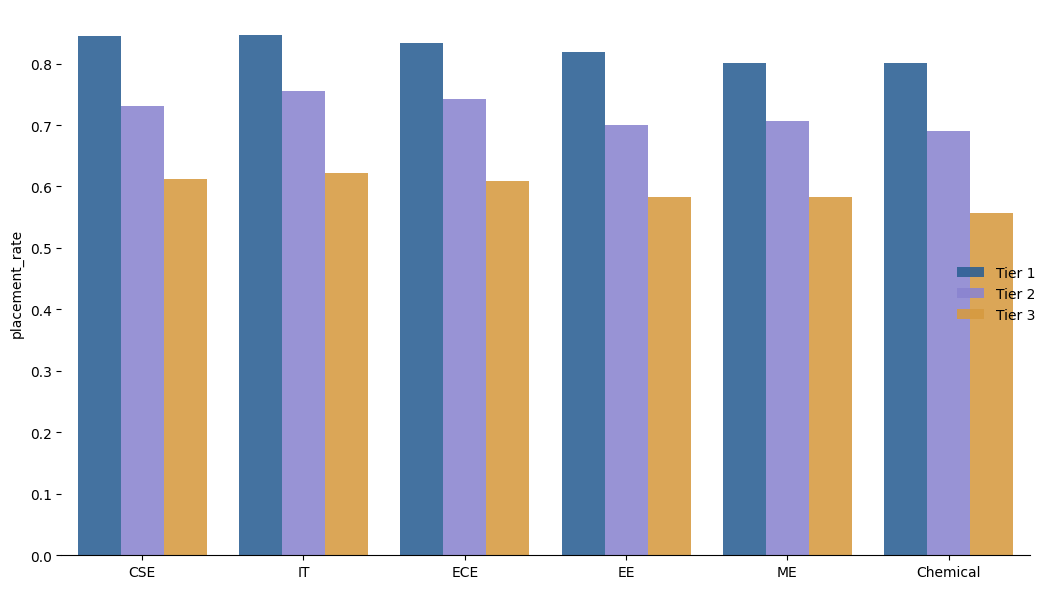

In [25]:
palette=["#185FA5", "#7F77DD", "#EF9F27"]
q1["tier_label"] = q1["college_tier"].map({1:"Tier 1", 2:"Tier 2", 3:"Tier 3"})

TIER_PAL   = {"Tier 1": "#185FA5", "Tier 2": "#7F77DD", "Tier 3": "#EF9F27"}
TIER_ORDER = ["Tier 1", "Tier 2", "Tier 3"]

g = sns.catplot(
    data=q1,
    kind="bar",
    x="branch",        y="placement_rate",
    hue="tier_label",              # ← string column, matches dict keys
    hue_order=TIER_ORDER,
    order=["CSE", "IT", "ECE", "EE", "ME", "Chemical"],
    palette=TIER_PAL,              # ← dict keys now match
    alpha=0.88,
    errorbar="sd",
    height=6, aspect=1.6,
)
g.despine(left=True)
g.set_axis_labels("", "placement_rate")
g.legend.set_title("")
plt.tight_layout()
plt.show()


What does the skill profile of a placed student look like compared to an unplaced one?

In [26]:
q2 = (
    df.groupby('placement_status')[['tech_skill','soft_skill','practical_skill','academic_points']]
    .mean()
).reset_index()

q2['placement_label'] = q2['placement_status'].astype(str).map({'1': 'Placed', '0': 'Not Placed'})
q2

,placement_status,tech_skill,soft_skill,practical_skill,academic_points,placement_label
0,0,0.460731,0.463993,0.305272,0.588205,Not Placed
1,1,0.480142,0.471461,0.340865,0.633728,Placed


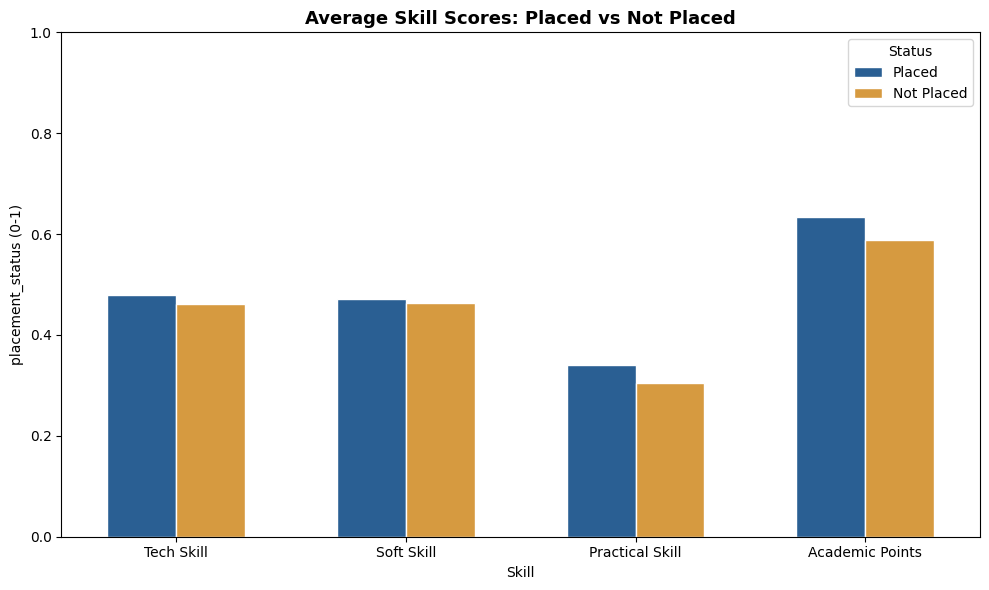

In [27]:
# melt to long format so seaborn can group by skill
q2_melt = q2.melt(
    id_vars='placement_label',
    value_vars=['tech_skill', 'soft_skill', 'practical_skill', 'academic_points'],
    var_name='skill',
    value_name='avg_score'
)

# clean up skill names for the chart
q2_melt['skill'] = q2_melt['skill'].map({
    'tech_skill':      'Tech Skill',
    'soft_skill':      'Soft Skill',
    'practical_skill': 'Practical Skill',
    'academic_points': 'Academic Points',
})

# plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q2_melt,
    x='skill',
    y='avg_score',
    hue='placement_label',
    hue_order=['Placed', 'Not Placed'],
    palette={'Placed': '#185FA5', 'Not Placed': '#EF9F27'},
    edgecolor='white',
    width=0.6,
)

plt.title('Average Skill Scores: Placed vs Not Placed', fontsize=13, fontweight='bold')
plt.xlabel('Skill')
plt.ylabel('placement_status (0-1)')
plt.ylim(0, 1)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

"Do academic performance indicators (CGPA, backlogs, academic points) strongly correlate with getting placed — or with salary?"

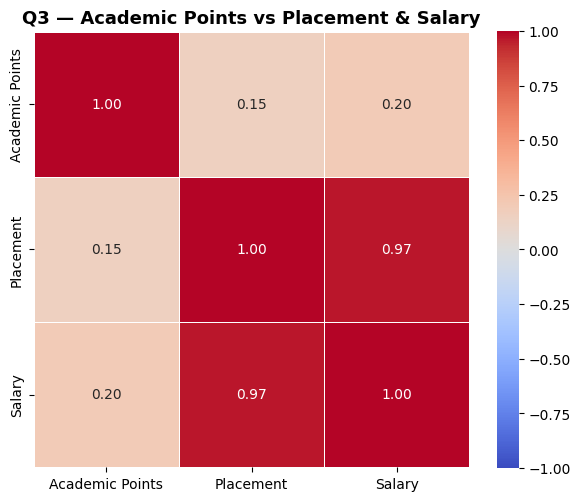

In [28]:
corr_cols = ['academic_points', 'placement_status', 'salary_package_lpa']

corr = df[corr_cols].corr()

# rename for readable labels
corr.columns = ['Academic Points', 'Placement', 'Salary']
corr.index   = ['Academic Points', 'Placement', 'Salary']

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Q3 — Academic Points vs Placement & Salary',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Q4 — Tier Bias: Does college tier advantage persist across skill levels?

C:\Users\MSI\AppData\Local\Temp\ipykernel_35848\1887859101.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['skill_bucket', 'college_tier'])['placement_status']


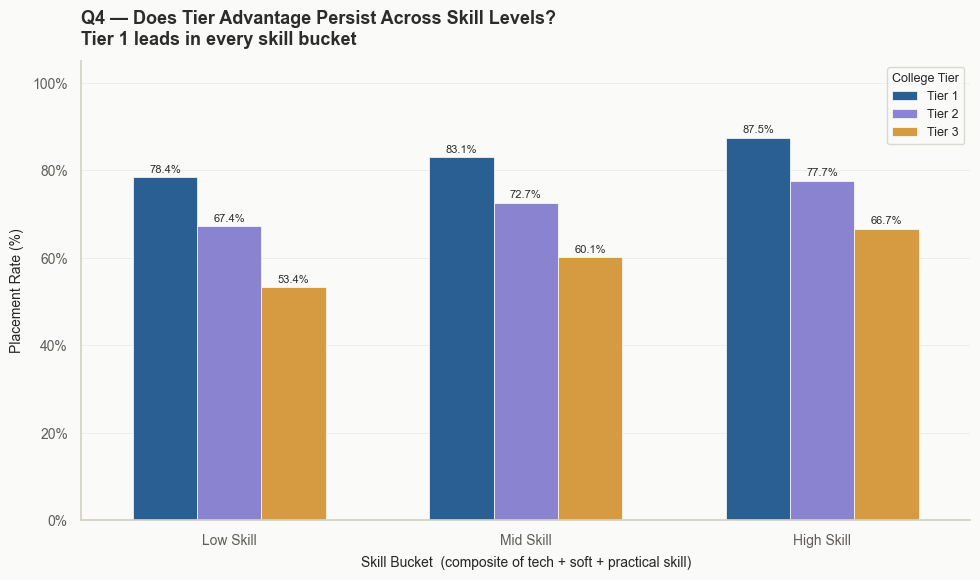

In [30]:
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': '#FAFAF9',
    'axes.facecolor':   '#FAFAF9',
    'axes.edgecolor':   '#D3D1C7',
    'grid.color':       '#EBEBEB',
    'grid.linewidth':   0.6,
})
 
TIER_PAL   = {'Tier 1': '#185FA5', 'Tier 2': '#7F77DD', 'Tier 3': '#EF9F27'}
TIER_ORDER = ['Tier 1', 'Tier 2', 'Tier 3']
df['composite_skill'] = (df['tech_skill'] + df['soft_skill'] + df['practical_skill']) / 3
df['skill_bucket']    = pd.qcut(df['composite_skill'], q=3,
                                labels=['Low Skill', 'Mid Skill', 'High Skill'])
 
q4 = (
    df.groupby(['skill_bucket', 'college_tier'])['placement_status']
    .mean()
    .reset_index()
)
q4['placement_pct'] = q4['placement_status'] * 100
q4['tier_label']    = q4['college_tier'].map({1:'Tier 1', 2:'Tier 2', 3:'Tier 3'})
 
BUCKET_ORDER = ['Low Skill', 'Mid Skill', 'High Skill']
 
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FAFAF9')
 
sns.barplot(
    data=q4,
    x='skill_bucket', y='placement_pct',
    hue='tier_label', hue_order=TIER_ORDER,
    order=BUCKET_ORDER,
    palette=TIER_PAL,
    edgecolor='white', linewidth=0.5,
    width=0.65, ax=ax,
)
 
# value labels
for bar in ax.patches:
    h = bar.get_height()
    if h > 1:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.6,
                f'{h:.1f}%', ha='center', va='bottom',
                fontsize=8, color='#2C2C2A')
 
ax.set_title('Q4 — Does Tier Advantage Persist Across Skill Levels?\n'
             'Tier 1 leads in every skill bucket',
             fontsize=13, fontweight='bold', pad=12, loc='left', color='#2C2C2A')
ax.set_xlabel('Skill Bucket  (composite of tech + soft + practical skill)',
              fontsize=10, labelpad=6)
ax.set_ylabel('Placement Rate (%)', fontsize=10, labelpad=6)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#D3D1C7')
ax.tick_params(labelsize=10, colors='#5F5E5A')
ax.legend(title='College Tier', fontsize=9, title_fontsize=9,
          framealpha=0.8, edgecolor='#D3D1C7')
 
plt.tight_layout()

plt.show()

Q5 — Salary Drivers: What predicts higher salary among placed students?
"""

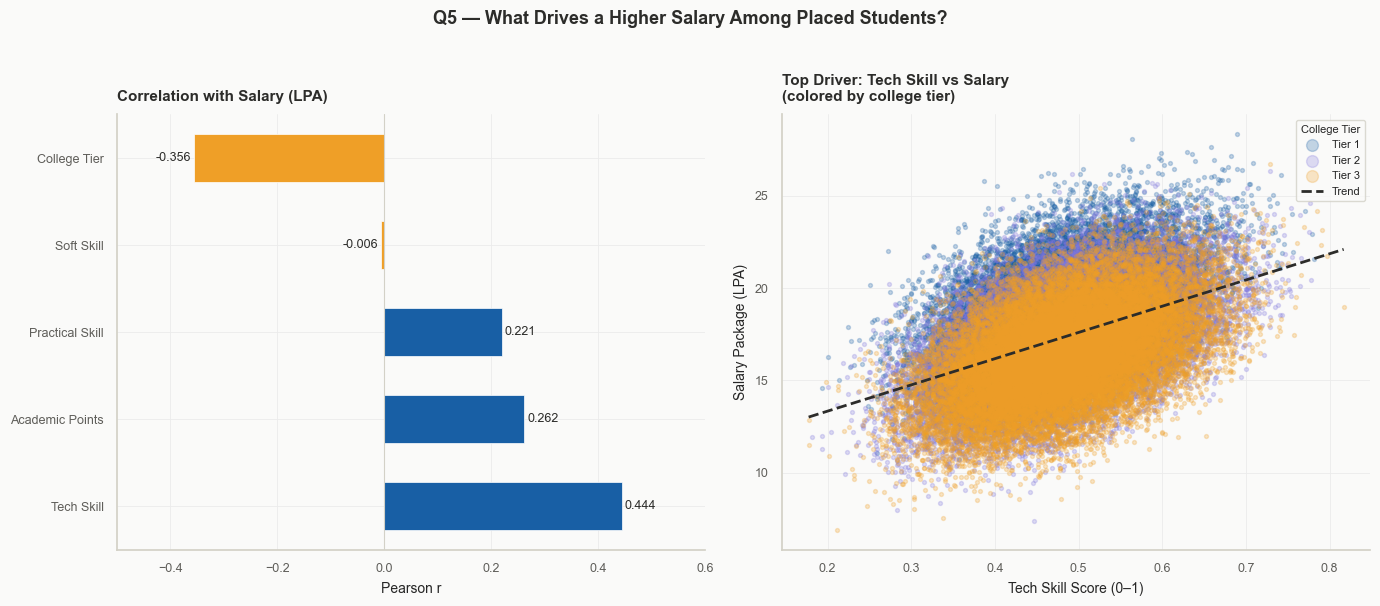

In [31]:
placed = df[df['placement_status'] == 1].copy()
placed['tier_label'] = placed['college_tier'].map({1:'Tier 1', 2:'Tier 2', 3:'Tier 3'})
 
corr_cols = ['tech_skill', 'soft_skill', 'practical_skill',
             'academic_points', 'college_tier', 'salary_package_lpa']
 
corr = placed[corr_cols].corr()[['salary_package_lpa']].drop('salary_package_lpa')
corr.index = ['Tech Skill', 'Soft Skill', 'Practical Skill',
              'Academic Points', 'College Tier']
corr = corr.sort_values('salary_package_lpa', ascending=False)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#FAFAF9')
 
# ── left: correlation bar ─────────────────────────────────────────────────
ax_l = axes[0]
colors = ['#185FA5' if v >= 0 else '#EF9F27'
          for v in corr['salary_package_lpa']]
 
ax_l.barh(corr.index, corr['salary_package_lpa'],
          color=colors, edgecolor='white', linewidth=0.5, height=0.55)
ax_l.axvline(0, color='#D3D1C7', linewidth=0.8)
 
for i, (idx, row) in enumerate(corr.iterrows()):
    v = row['salary_package_lpa']
    x_pos = v + 0.005 if v >= 0 else v - 0.005
    ha = 'left' if v >= 0 else 'right'
    ax_l.text(x_pos, i, f'{v:.3f}', va='center',
              fontsize=9, color='#2C2C2A', ha=ha)
 
ax_l.set_title('Correlation with Salary (LPA)', fontsize=11,
               fontweight='bold', pad=10, color='#2C2C2A', loc='left')
ax_l.set_xlabel('Pearson r', fontsize=10, labelpad=5)
ax_l.spines[['top', 'right']].set_visible(False)
ax_l.spines[['left', 'bottom']].set_color('#D3D1C7')
ax_l.tick_params(labelsize=9, colors='#5F5E5A')
ax_l.set_xlim(-0.5, 0.6)
 
# ── right: scatter top feature vs salary ─────────────────────────────────
ax_r = axes[1]
 
for tier in TIER_ORDER:
    grp = placed[placed['tier_label'] == tier]
    ax_r.scatter(
        grp['tech_skill'], grp['salary_package_lpa'],
        color=TIER_PAL[tier], alpha=0.25, s=8, label=tier,
    )
 
# regression line
m, b = np.polyfit(placed['tech_skill'], placed['salary_package_lpa'], 1)
xs = np.linspace(placed['tech_skill'].min(), placed['tech_skill'].max(), 100)
ax_r.plot(xs, m * xs + b, color='#2C2C2A', linewidth=2,
          linestyle='--', label='Trend')
 
ax_r.set_title('Top Driver: Tech Skill vs Salary\n(colored by college tier)',
               fontsize=11, fontweight='bold', pad=10,
               color='#2C2C2A', loc='left')
ax_r.set_xlabel('Tech Skill Score (0–1)', fontsize=10, labelpad=5)
ax_r.set_ylabel('Salary Package (LPA)', fontsize=10, labelpad=5)
ax_r.spines[['top', 'right']].set_visible(False)
ax_r.spines[['left', 'bottom']].set_color('#D3D1C7')
ax_r.tick_params(labelsize=9, colors='#5F5E5A')
ax_r.legend(title='College Tier', fontsize=8, title_fontsize=8,
            framealpha=0.8, edgecolor='#D3D1C7', markerscale=3)
 
fig.suptitle('Q5 — What Drives a Higher Salary Among Placed Students?',
             fontsize=13, fontweight='bold', y=1.01, color='#2C2C2A')
 
plt.tight_layout()
plt.show()